## California Housing
Датасет: `sklearn.datasets.fetch_california_housing` — данные переписи населения Калифорнии (1990), 20640 объектов, 8 признаков.

**Задача:** предсказать медианную стоимость жилья по районам Калифорнии на основе демографических и географических данных.

Был проведен EDA, в ходе которого не выявлены пропуски в наборе данных. Корреляция целевого признака MedHouseVal с другими продемонстрировала высокий показатель (≈0.69) для MedInc. Остальные результаты значительно ниже (в диапазоне [-0.1, 0.1]).

Обучены 3 модели, использованы метрики MSE и R2: линейная регрессия (MSE=0.556, R2=0.576), дерево решений (MSE=0.495, R2=0.622) и случайный лес (MSE=0.255, R2=0.805). Случайный лес продемонстрировал лучшие результаты из представленных, вероятно, по причине нелинейных зависимостей между признаками и большого количества объектов (20640) в выбранном датасете.

Был проведен анализ важности признаков на основе обученного случайного леса. Latitude и Longitude заняли 3-4 места по важности (≈0.09 каждый, суммарно ~18%), несмотря на околонулевую корреляцию с целевой переменной. Это указывает на нелинейный характер их влияния, который корреляционный анализ уловить не способен.

При анализе графиков предсказаний и остатков целевой переменной была обнаружена намеренно заданная верхняя граница (5.0), из-за чего модель систематически занижает стоимость дорогого жилья.


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

In [2]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [3]:
df.corr()['MedHouseVal'].sort_values(ascending=False)

,MedHouseVal
MedHouseVal,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {'Linear Regression': LinearRegression(),
          'Decision Tree': DecisionTreeRegressor(random_state=42),
          'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100)}
for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f"{name}: MSE = {mse:.3f}, R2 = {r2:.3f}")

Linear Regression: MSE = 0.556, R2 = 0.576
Decision Tree: MSE = 0.495, R2 = 0.622
Random Forest: MSE = 0.255, R2 = 0.805


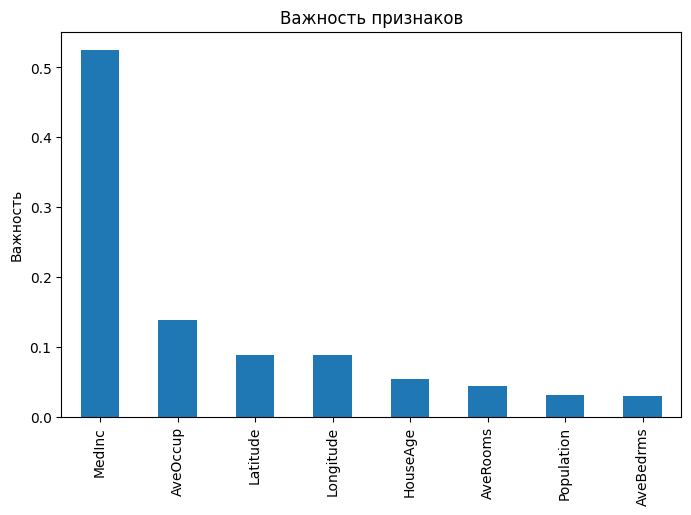

MedInc        0.524871
AveOccup      0.138443
Latitude      0.088936
Longitude     0.088629
HouseAge      0.054593
AveRooms      0.044272
Population    0.030650
AveBedrms     0.029606
dtype: float64


In [9]:
import matplotlib.pyplot as plt

rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar')
plt.title('Важность признаков')
plt.ylabel('Важность')
plt.show()

print(feat_imp)

Text(0.5, 1.0, 'Random Fores: предсказания vs реальность')

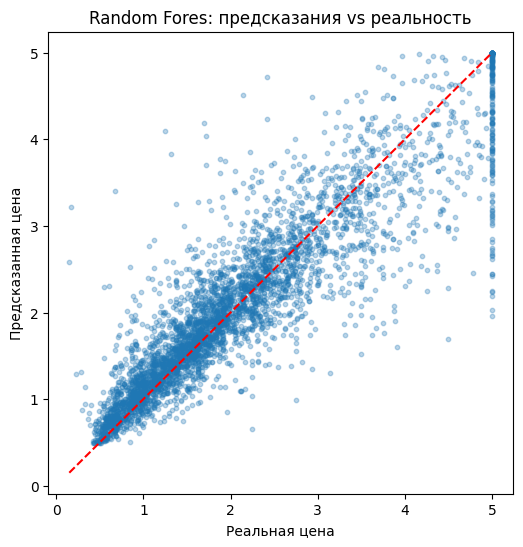

In [10]:
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Random Fores: предсказания vs реальность')

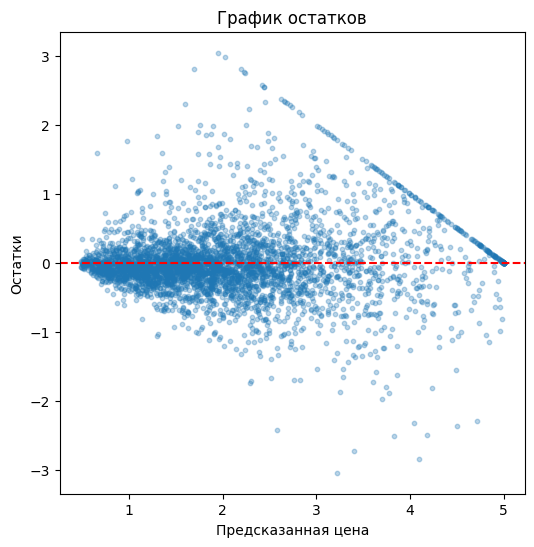

In [11]:
residuals = y_test - y_pred_best

plt.figure(figsize=(6, 6))
plt.scatter(y_pred_best, residuals, alpha=0.3, s=10)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанная цена')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.show()